In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn

In [2]:
df = pd.read_csv("powerplat_data.csv")
df.isnull().sum()
df.head()
df.shape

(9568, 5)

In [3]:
X = df.drop("PE", axis = 1)
y = df["PE"] 

In [4]:
# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [5]:
#scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
#Converting the data into Tensors(PyTorch core data structures)
X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1,1)#y_train is not scaled and still a numpy array so we use values for that
#.view changes the dimensions - [1,2,3,4] -> [[1], [2], [3], [4]], -1 means detect automatically
X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1,1)

#all the tensors will be stored in RAM of our computer

In [7]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [8]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32)

# deep learning

In [10]:
#define ANN model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),

            #output layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)
    #backward propagation is automatically handled by pytorch using autograd(automatic gradient decent engine)

In [11]:
import torch.optim as optim
model = ANN()

# loss, optimiser
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

# train the ANN

In [12]:
train_losses = []
valid_losses = []

best_vali_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # save the total training loss of one epoch

    for xb, yb in train_loader:
        # xb is features of one batch yb is labels of one batch
        optimizer.zero_grad() # this helps in doing old gradients to zero
        outputs = model(xb) #forward propagation step -> predicted outputs
        loss = criterion(outputs, yb) #compute loss
        loss.backward() #back propagation .. compute gradients
        optimizer.step() # update params
        
        running_loss += loss.item() # loss is a tensor value => python float value

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    #validation
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad(): # no gradient compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss
            
    epoch_val_loss = running_val_loss / len(test_loader)
    valid_losses.append(epoch_val_loss)

    print(f"Epoch {epoch + 1}/ {epochs} ==> traning loss = {epoch_train_loss} & val loss {epoch_val_loss}")

    if epoch_val_loss < best_vali_loss:
        best_vali_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model_for_regression.pt") #.pt file or pth file to save models parameters

Epoch 1/ 100 ==> traning loss = 205949.31549479166 & val loss 204059.84375
Epoch 2/ 100 ==> traning loss = 196815.04694010416 & val loss 185103.546875
Epoch 3/ 100 ==> traning loss = 164308.44016927082 & val loss 139784.0625
Epoch 4/ 100 ==> traning loss = 110432.50540364583 & val loss 82236.734375
Epoch 5/ 100 ==> traning loss = 58506.935725911455 & val loss 40294.7890625
Epoch 6/ 100 ==> traning loss = 29961.703206380207 & val loss 23762.154296875
Epoch 7/ 100 ==> traning loss = 20809.390852864584 & val loss 18787.33984375
Epoch 8/ 100 ==> traning loss = 17216.81563313802 & val loss 15761.673828125
Epoch 9/ 100 ==> traning loss = 14356.275504557292 & val loss 12899.7080078125
Epoch 10/ 100 ==> traning loss = 11594.22096150716 & val loss 10129.1025390625
Epoch 11/ 100 ==> traning loss = 8941.139815266926 & val loss 7537.0009765625
Epoch 12/ 100 ==> traning loss = 6456.2015665690105 & val loss 5256.1357421875
Epoch 13/ 100 ==> traning loss = 4370.967058308919 & val loss 3420.0012207031

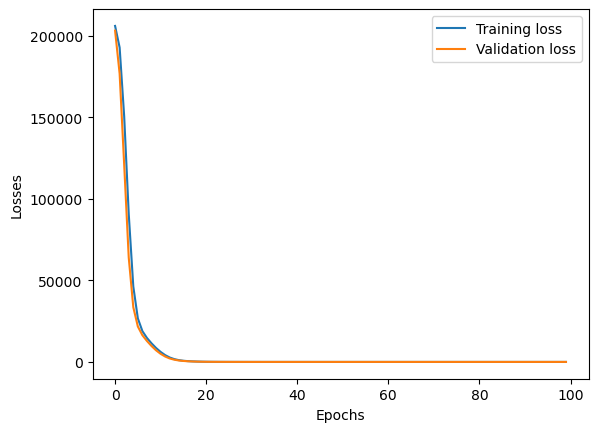

In [48]:
import matplotlib.pyplot as plt
loss_df = pd.DataFrame({
    "training_loss": train_losses,
    "validation_loss" : valid_losses
})
plt.plot(loss_df["training_loss"], label = "Training loss")
plt.plot(loss_df["validation_loss"], label = "Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

In [49]:
# Loading the best model

model.load_state_dict(torch.load("best_model_for_regression.pt"))

<All keys matched successfully>

In [50]:
# evaluate our model

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)
print(f"Training mse {train_mse_loss.item()}")
print(f"Testing mse {test_mse_loss.item()}")

Training mse 21.257360458374023
Testing mse 19.548931121826172


In [51]:
from sklearn.metrics import r2_score
print(f"r2_score for trainig data is {r2_score(train_preds,y_train_tensor)}")
print(f"r2_score for test data is {r2_score(train_preds,y_train_tensor)}")

r2_score for trainig data is 0.920295774936676
r2_score for test data is 0.920295774936676


In [52]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns = ["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns = ["Actual Values"])

pd.concat([predicted_df, actual_df], axis = 1)

,Predicted Values,Actual Values
0,435.601410,433.27
1,437.183136,438.16
2,461.005890,458.42
3,475.684143,480.82
4,435.600555,441.41
...,...,...
1909,451.309174,456.70
1910,431.996857,438.04
1911,467.333984,467.80
1912,431.444000,437.14


In [26]:
# comparing it to linear ml model
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
y_pred = lr.predict(X_test)
y_pred_train = lr.predict(X_train)
print(f"r2_score for testing data in ml {r2_score(y_test, y_pred)}")
print(f"r2_score for training data in ml {r2_score(y_train, y_pred_train)}")

r2_score for testing data in ml 0.9314747936670361
r2_score for training data in ml 0.9279951490925766
